In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/kaggle/input/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nAttrition Value Counts:")
print(df['Attrition'].value_counts())
df.head()


FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv'

In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/nikitajoshidata8/hr-attrition/WA_Fn-UseC_-HR-Employee-Attrition.csv


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/kaggle/input/datasets/nikitajoshidata8/hr-attrition/WA_Fn-UseC_-HR-Employee-Attrition.csv')

print("Shape:", df.shape)
print("\nAttrition Value Counts:")
print(df['Attrition'].value_counts())
print("\nAttrition Rate:")
print(round(df['Attrition'].value_counts(normalize=True) * 100, 2))
df.head()

Shape: (1470, 35)

Attrition Value Counts:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Rate:
Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
# Check missing values and duplicates
print("Missing Values:")
print(df.isnull().sum().sum())

print("\nDuplicates:", df.duplicated().sum())

# These columns have only one value, useless for analysis
print("\nUseless Columns:")
print(df['Over18'].value_counts())
print(df['StandardHours'].value_counts())
print(df['EmployeeCount'].value_counts())

# Drop useless columns
df = df.drop(['Over18', 'StandardHours', 'EmployeeCount'], axis=1)
print("\nNew Shape:", df.shape)

Missing Values:
0

Duplicates: 0

Useless Columns:
Over18
Y    1470
Name: count, dtype: int64
StandardHours
80    1470
Name: count, dtype: int64
EmployeeCount
1    1470
Name: count, dtype: int64

New Shape: (1470, 32)


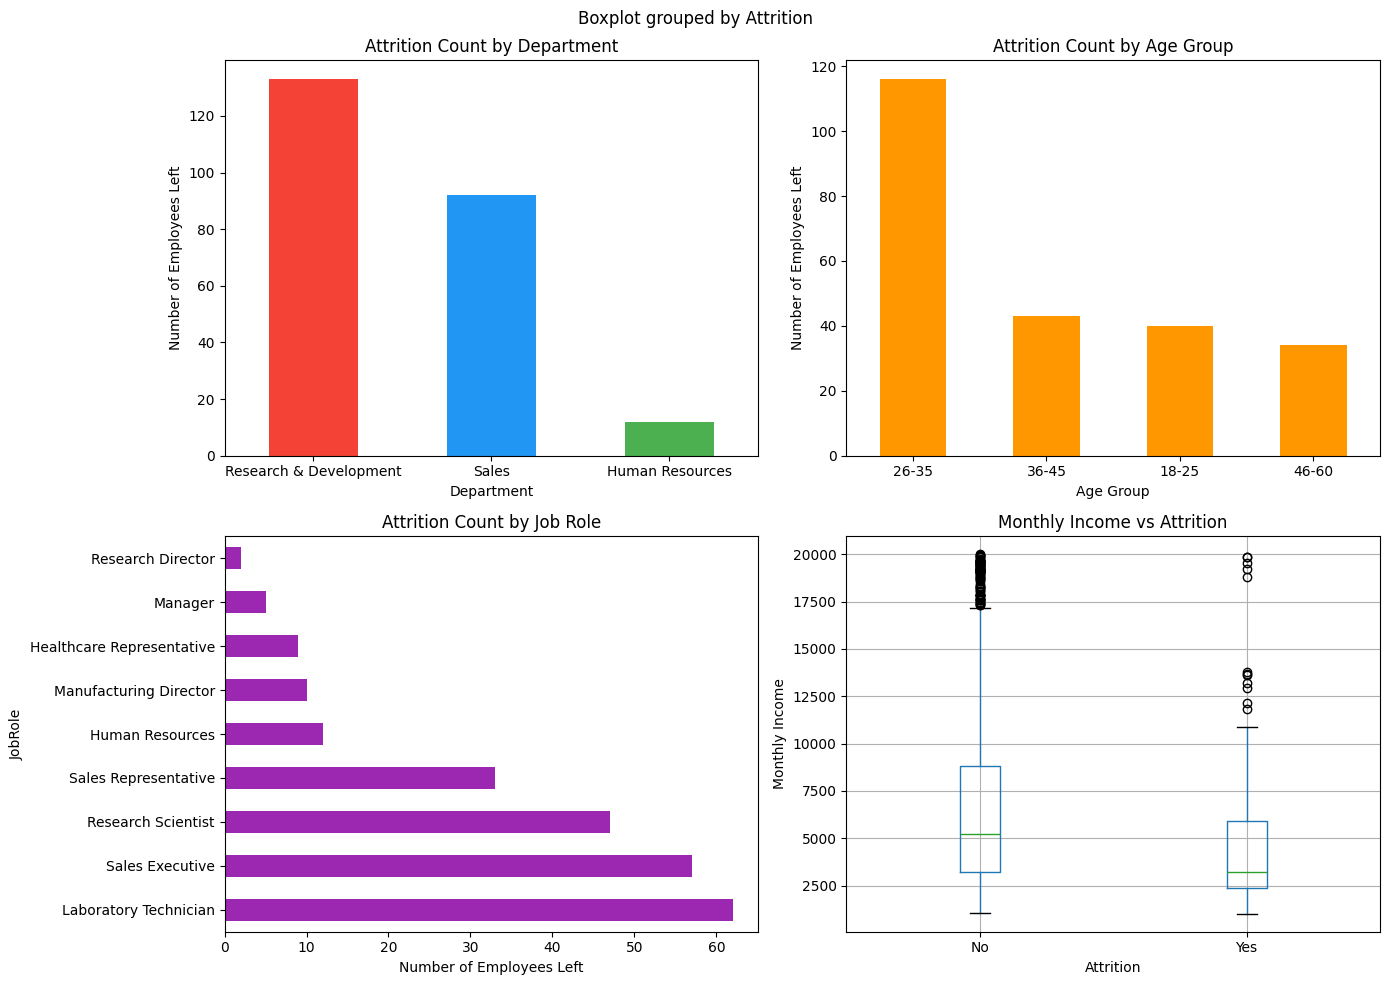

Charts saved.


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('HR Attrition Analysis', fontsize=16)

# Chart 1: Attrition by Department
dept_attrition = df[df['Attrition']=='Yes']['Department'].value_counts()
dept_attrition.plot(kind='bar', ax=axes[0,0], color=['#F44336','#2196F3','#4CAF50'])
axes[0,0].set_title('Attrition Count by Department')
axes[0,0].set_xlabel('Department')
axes[0,0].set_ylabel('Number of Employees Left')
axes[0,0].tick_params(axis='x', rotation=0)

# Chart 2: Attrition by Age Group
df['AgeGroup'] = pd.cut(df['Age'], bins=[18,25,35,45,60], 
                         labels=['18-25','26-35','36-45','46-60'])
age_attrition = df[df['Attrition']=='Yes']['AgeGroup'].value_counts()
age_attrition.plot(kind='bar', ax=axes[0,1], color='#FF9800')
axes[0,1].set_title('Attrition Count by Age Group')
axes[0,1].set_xlabel('Age Group')
axes[0,1].set_ylabel('Number of Employees Left')
axes[0,1].tick_params(axis='x', rotation=0)

# Chart 3: Attrition by Job Role
role_attrition = df[df['Attrition']=='Yes']['JobRole'].value_counts()
role_attrition.plot(kind='barh', ax=axes[1,0], color='#9C27B0')
axes[1,0].set_title('Attrition Count by Job Role')
axes[1,0].set_xlabel('Number of Employees Left')

# Chart 4: Attrition by Monthly Income
df.boxplot(column='MonthlyIncome', by='Attrition', ax=axes[1,1])
axes[1,1].set_title('Monthly Income vs Attrition')
axes[1,1].set_xlabel('Attrition')
axes[1,1].set_ylabel('Monthly Income')

plt.tight_layout()
plt.savefig('attrition_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Charts saved.")

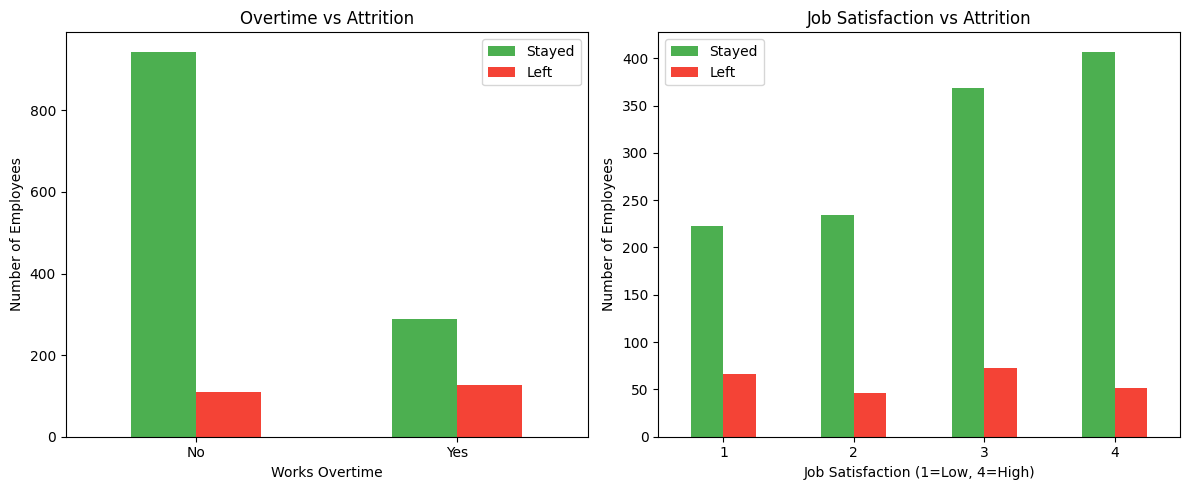

Charts saved.


In [6]:
# Overtime vs Attrition
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

overtime = df.groupby(['OverTime','Attrition']).size().unstack()
overtime.plot(kind='bar', ax=axes[0], color=['#4CAF50','#F44336'])
axes[0].set_title('Overtime vs Attrition')
axes[0].set_xlabel('Works Overtime')
axes[0].set_ylabel('Number of Employees')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(['Stayed','Left'])

# Job Satisfaction vs Attrition
satisfaction = df.groupby(['JobSatisfaction','Attrition']).size().unstack()
satisfaction.plot(kind='bar', ax=axes[1], color=['#4CAF50','#F44336'])
axes[1].set_title('Job Satisfaction vs Attrition')
axes[1].set_xlabel('Job Satisfaction (1=Low, 4=High)')
axes[1].set_ylabel('Number of Employees')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(['Stayed','Left'])

plt.tight_layout()
plt.savefig('attrition_factors.png', dpi=150, bbox_inches='tight')
plt.show()
print("Charts saved.")

# HR Attrition Analysis: Business Insights

## Project Summary
Analysed 1,470 employee records across 32 variables to identify 
key drivers of employee attrition. Overall attrition rate: 16.12%.
237 out of 1,470 employees left the company.

## Key Findings

### 1. Research and Development Has Highest Attrition
R&D department accounts for the largest number of employees leaving.
Immediate retention focus needed in this department.

### 2. Young Professionals Leave Most
Age group 26-35 has the highest attrition count. These are 
mid-career professionals likely seeking better opportunities 
and higher salaries elsewhere.

### 3. Overtime is a Major Attrition Driver
Employees who work overtime leave at a significantly higher rate.
Burnout and work-life imbalance are likely causes.

### 4. Low Income Drives Attrition
Employees who left had significantly lower monthly income than 
those who stayed. Salary competitiveness is a key retention factor.

### 5. Low Job Satisfaction Predicts Attrition
Employees with satisfaction score 1 show the highest leaving rate.
Regular satisfaction surveys and action plans are essential.

## Business Recommendations
1. Review overtime policies in R&D department immediately.
2. Create salary review program targeting employees earning 
   below market rate, especially in 26-35 age group.
3. Implement quarterly job satisfaction surveys with 
   mandatory action plans for scores below 2.
4. Build career growth programs for Laboratory Technicians 
   and Sales Executives, the two highest attrition roles.

In [7]:
print("HR Attrition Analysis Complete")
print("Total Employees Analysed: 1,470")
print("Attrition Rate: 16.12%")
print("Charts Created: 6")
print("Key Findings: 5")
print("Business Recommendations: 4")

HR Attrition Analysis Complete
Total Employees Analysed: 1,470
Attrition Rate: 16.12%
Charts Created: 6
Key Findings: 5
Business Recommendations: 4
